# 02 — Feature Engineering

Goal: statistically characterize how each feature differs between classes, visualize correlations, and select a non-redundant feature subset for modeling.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_ind
import json
import os

sns.set_theme(style='whitegrid')
%matplotlib inline

REPORT_DIR = '../reports/02_feature_engineering'
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## Load Data

In [8]:
df = pd.read_csv('../data/raw/creditcard.csv')
all_features = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
print(df.shape)

(284807, 31)


## 1. Statistical Significance Test (Legit vs. Fraud)

For each feature, we test whether its distribution differs between the Legit and Fraud groups using two complementary tests:
- **Mann-Whitney U** — non-parametric, robust to the non-normal/heavy-tailed distributions seen in the PCA features and `Amount`.
- **Welch's t-test** — parametric, does not assume equal variances, included for comparison.

> Note: with n ≈ 285,000, even practically negligible differences will often be statistically significant. We use a stricter α = 0.001 (instead of the conventional 0.05) to partially compensate for this, but the results below are still for exploratory characterization only — feature selection below relies on correlation magnitude, not on this test.

In [9]:
ALPHA = 0.001
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

rows = []
for col in all_features:
    mw_stat, mw_p = mannwhitneyu(legit[col], fraud[col], alternative='two-sided')
    tt_stat, tt_p = ttest_ind(legit[col], fraud[col], equal_var=False)
    rows.append({
        'feature': col,
        'mannwhitney_p': mw_p,
        'mannwhitney_significant': mw_p < ALPHA,
        'welch_p': tt_p,
        'welch_significant': tt_p < ALPHA,
    })

sig_results = pd.DataFrame(rows).sort_values('mannwhitney_p').reset_index(drop=True)
sig_results.to_csv(f'{REPORT_DIR}/significance_test.csv', index=False)
sig_results

,feature,mannwhitney_p,mannwhitney_significant,welch_p,welch_significant
0,V14,1.471581e-260,True,1.040151e-140,True
1,V4,3.625904e-248,True,4.587317e-136,True
2,V12,8.416027e-247,True,1.481317e-112,True
3,V11,4.910592e-226,True,4.577212e-120,True
4,V10,9.611131e-222,True,3.382884e-93,True
5,V3,1.211048e-219,True,4.786081e-75,True
6,V2,1.650438e-163,True,1.288580e-59,True
7,V16,1.808172e-156,True,7.905326e-84,True
8,V9,8.943723e-154,True,1.193505e-79,True
9,V7,1.464234e-146,True,4.292231e-52,True


## 2. Correlation Heatmap (with Coefficients)

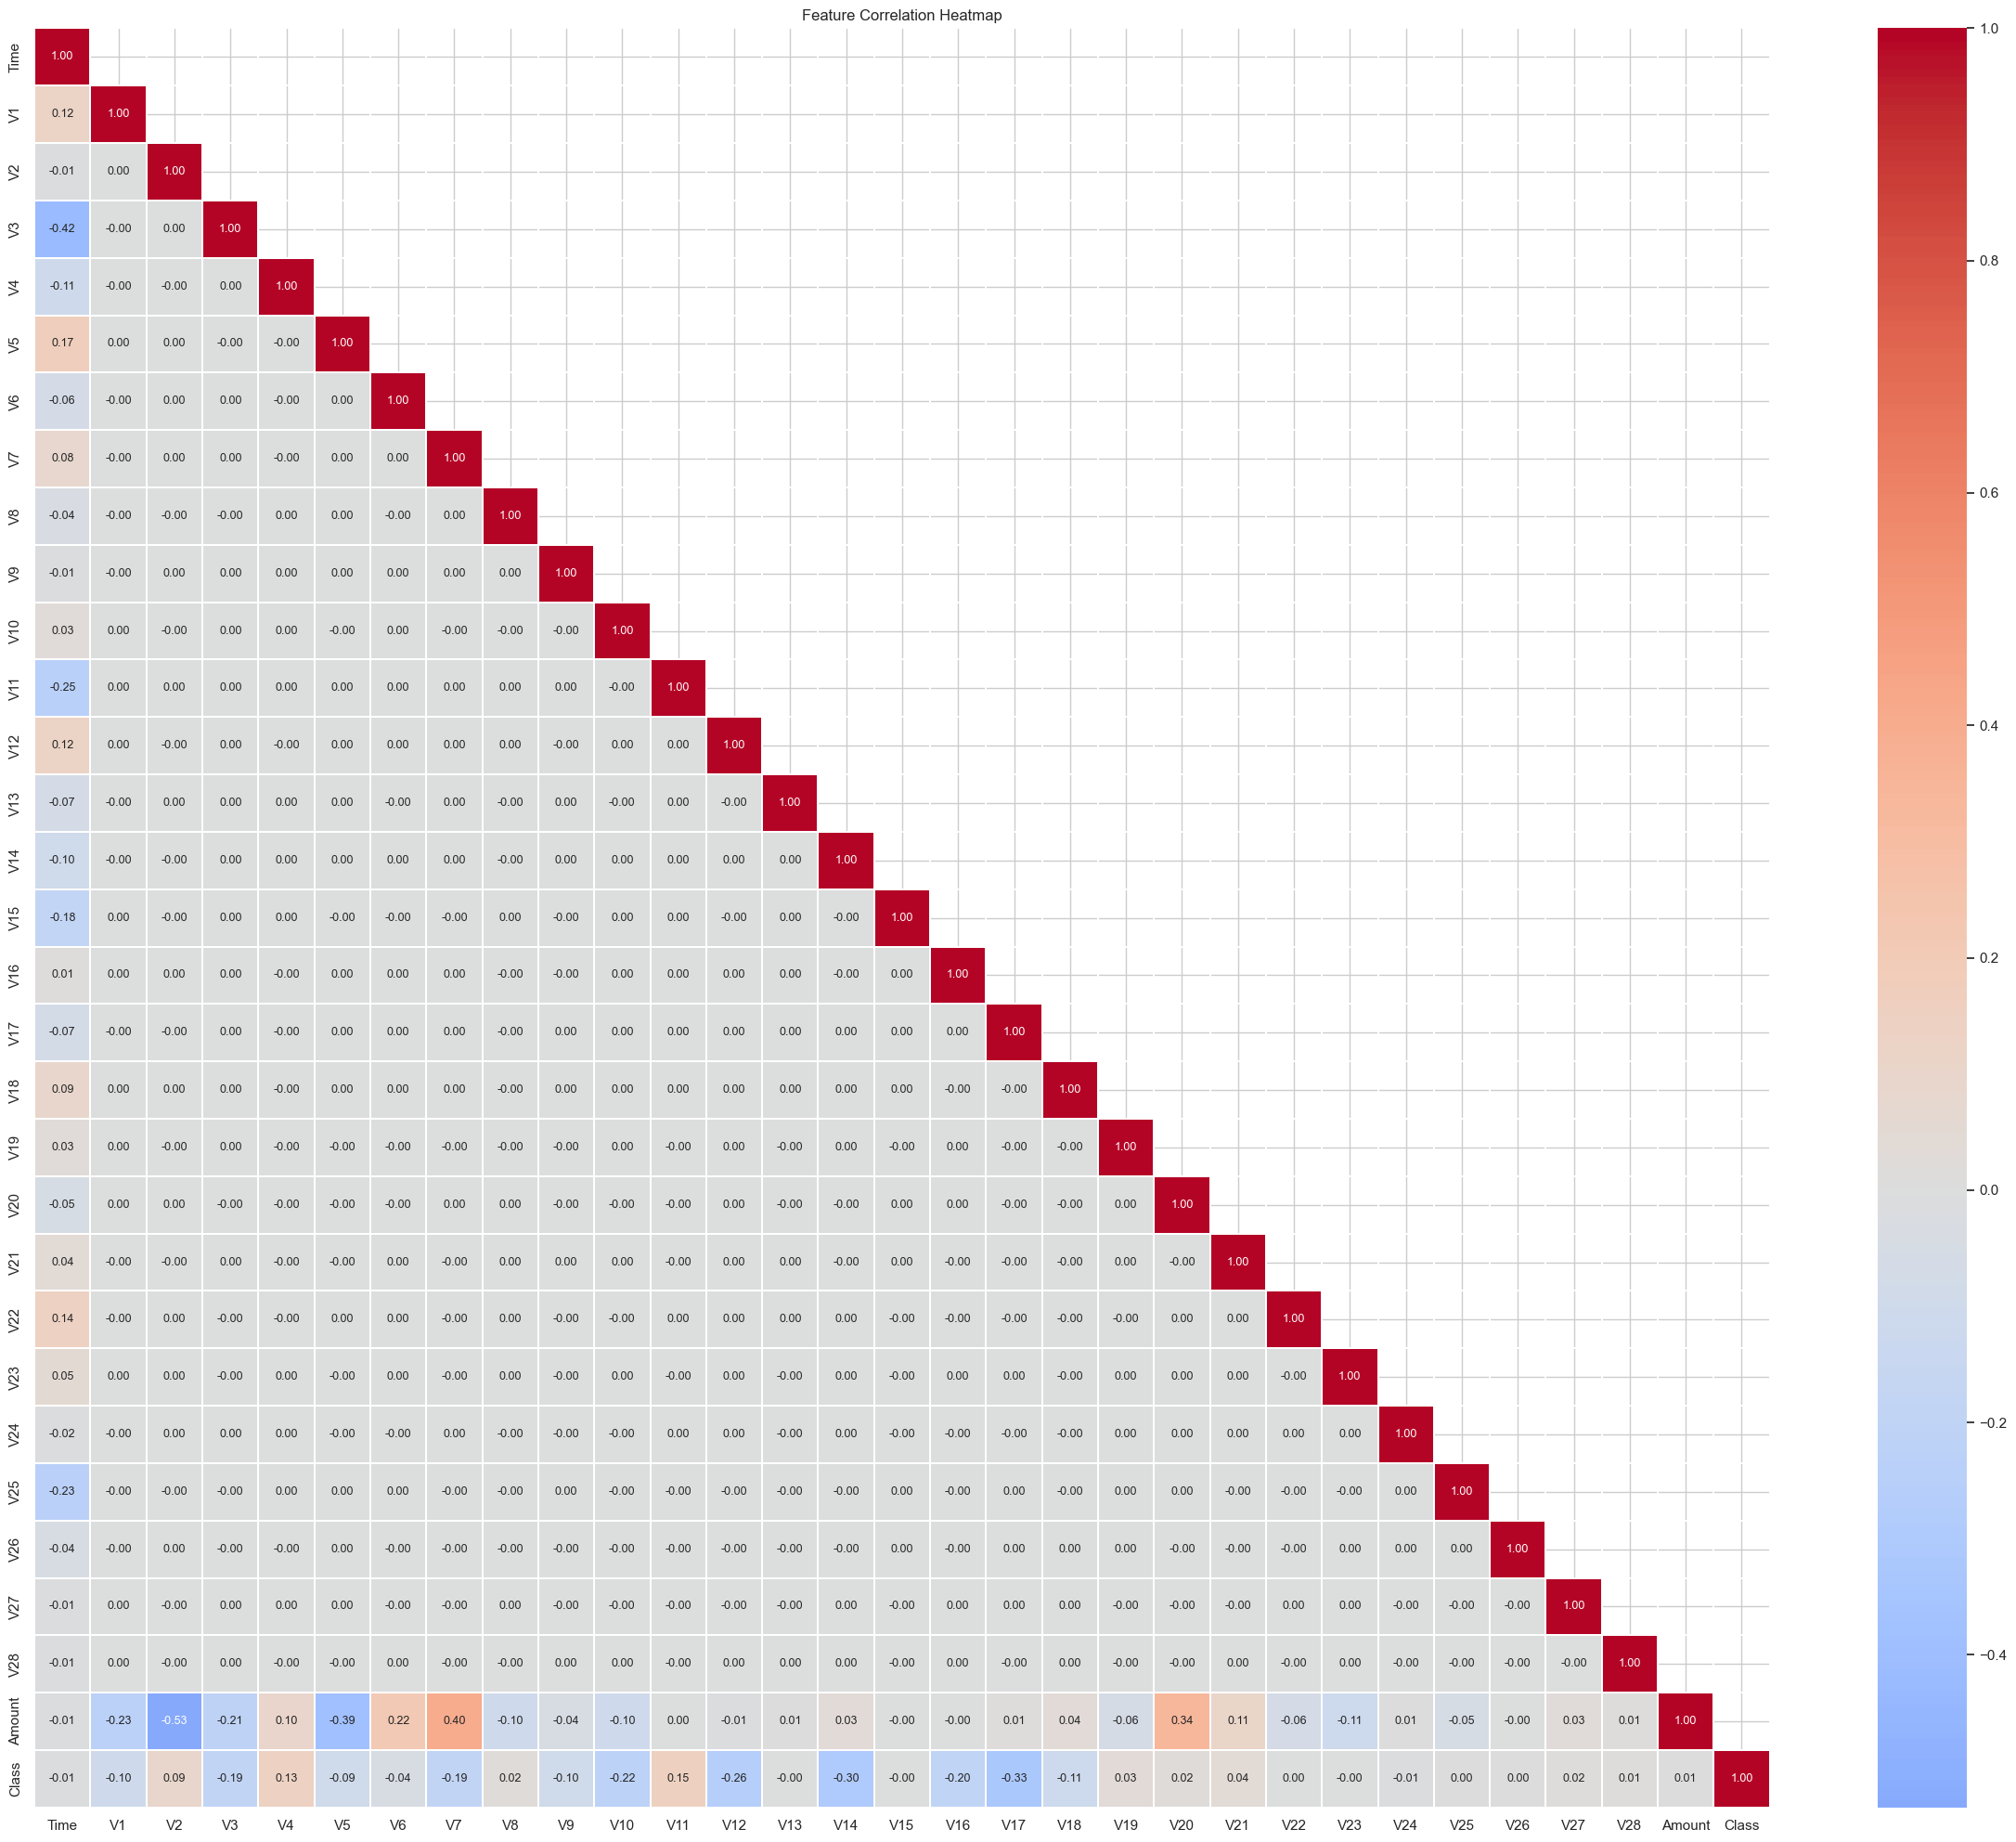

In [10]:
corr = df.corr()

# Mask the upper triangle (the matrix is symmetric) so the larger annotation
# font below remains readable.
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(24, 20))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.3,
            annot=True, fmt='.2f', annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/correlation_heatmap.png', dpi=100)
plt.show()

## 3. Feature Selection (Avoid Multicollinearity & Overfitting)

Greedy selection based only on correlation with `Class`:
1. Rank all 30 features by `|corr(feature, Class)|`, descending.
2. Walk the ranked list. Add a feature to the selected set only if its correlation with every already-selected feature is below the `0.3` threshold; otherwise drop it as redundant.

> The threshold is set to `0.3` because the observed max off-diagonal correlation in the heatmap above is only ~0.4 — a threshold of 0.7 would never drop anything. `04_modeling.ipynb` trains on both the full feature set and this selected subset and compares their PR-AUC directly, so if this filter turns out to be too aggressive, that's immediately visible rather than silently losing predictive signal.

Example: if `V7` is highly correlated with `Class` and gets selected first, and `Amount` turns out to be highly correlated with `V7` (> 0.3), `Amount` is dropped — `V7` already captures that signal.

In [11]:
CORR_THRESHOLD = 0.3

class_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)

selected = []
dropped = {}

for feature in class_corr.index:
    if not selected:
        selected.append(feature)
        continue
    corr_with_selected = corr.loc[feature, selected].abs()
    if corr_with_selected.max() < CORR_THRESHOLD:
        selected.append(feature)
    else:
        dropped[feature] = corr_with_selected.idxmax()

print(f'Selected {len(selected)} features: {selected}')
print(f'\nDropped {len(dropped)} features due to multicollinearity:')
for feature, redundant_with in dropped.items():
    print(f'  {feature} (redundant with {redundant_with}, |corr|={corr.loc[feature, redundant_with]:.3f})')

Selected 28 features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27', 'V28', 'V24', 'V13', 'V26', 'V15', 'V25', 'V23', 'V22']

Dropped 2 features due to multicollinearity:
  Time (redundant with V3, |corr|=-0.420)
  Amount (redundant with V2, |corr|=-0.531)


In [12]:
with open('../data/processed/selected_features.json', 'w') as f:
    json.dump(selected, f, indent=2)

summary = pd.DataFrame({
    'feature': class_corr.index,
    'class_corr': class_corr.values,
    'status': ['selected' if f in selected else 'dropped' for f in class_corr.index],
    'redundant_with': [dropped.get(f, '') for f in class_corr.index],
})
summary.to_csv(f'{REPORT_DIR}/feature_selection_summary.csv', index=False)

print('Saved: data/processed/selected_features.json')
print(f'Saved: {REPORT_DIR}/feature_selection_summary.csv')
summary

Saved: data/processed/selected_features.json
Saved: ../reports/02_feature_engineering/feature_selection_summary.csv


,feature,class_corr,status,redundant_with
0,V17,0.326481,selected,
1,V14,0.302544,selected,
2,V12,0.260593,selected,
3,V10,0.216883,selected,
4,V16,0.196539,selected,
5,V3,0.192961,selected,
6,V7,0.187257,selected,
7,V11,0.154876,selected,
8,V4,0.133447,selected,
9,V18,0.111485,selected,
